# Projeto Final — Aprendizado de Máquina

## Previsão de sobrevivência dos passageiros do Titanic

**Integrantes:** Matheuz Rozendo e Kayo Araujo


## Identificação e descrição do problema

**Fonte dos dados**: Titanic Dataset, disponibilizado no Kaggle por Yasser H.

**Link do dataset**: https://www.kaggle.com/datasets/yasserh/titanic-dataset

**Objetivo**: desenvolver e comparar modelos de aprendizado de máquina capazes de prever se um passageiro do Titanic sobreviveu, utilizando suas características registradas no conjunto de dados.

**Atributo-alvo**: Survived, em que 0 representa um passageiro que não sobreviveu e 1 representa um passageiro que sobreviveu.

**Atributos preditivos**: `Pclass`, `Sex`, `Age`, `SibSp`, `Parch`, `Fare` e `Embarked`.

**Tipo da tarefa**: classificação binária, pois o atributo-alvo possui duas categorias possíveis -- sobreviveu ou não sobreviveu.

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [49]:
dados = pd.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/refs/heads/master/titanic.csv")

dados.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Compreensão dos dados

In [50]:
dados.shape

(891, 12)

In [51]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [53]:
dados.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


### Valores ausentes

Foram encontrados valores ausentes nas colunas `Age`, `Cabin` e `Embarked`. A coluna `Age` possui 177 valores ausentes, `Cabin` possui 687 e `Embarked` possui 2. As demais colunas não apresentam valores ausentes.

In [10]:
dados.duplicated().sum()

np.int64(0)

### Duplicações

Não foram encontradas linhas duplicadas no conjunto de dados.

In [54]:
colunas_categoricas_verificacao = [
    "Survived",
    "Pclass",
    "Sex",
    "Embarked"
]

for coluna in colunas_categoricas_verificacao:
    print(f"{coluna}: {dados[coluna].dropna().unique()}")

dados[["Age", "Fare", "SibSp", "Parch"]].describe()

Survived: [0 1]
Pclass: [3 1 2]
Sex: ['male' 'female']
Embarked: ['S' 'C' 'Q']


,Age,Fare,SibSp,Parch
count,714.000000,891.000000,891.000000,891.000000
mean,29.699118,32.204208,0.523008,0.381594
std,14.526497,49.693429,1.102743,0.806057
min,0.420000,0.000000,0.000000,0.000000
25%,20.125000,7.910400,0.000000,0.000000
50%,28.000000,14.454200,0.000000,0.000000
75%,38.000000,31.000000,1.000000,0.000000
max,80.000000,512.329200,8.000000,6.000000


### Verificação de inconsistências

As categorias observadas nas colunas Survived, Pclass, Sex e Embarked correspondem aos valores esperados para o conjunto de dados. Não foram encontradas categorias inválidas nessas variáveis.

A idade dos passageiros varia de aproximadamente 0,42 a 80 anos, enquanto a tarifa varia de 0 a aproximadamente 512,33. Foram observadas tarifas muito elevadas, mas esses registros foram mantidos por representarem valores possíveis no contexto das diferentes classes e acomodações do navio, e não erros evidentes de preenchimento.

## Análise exploratória

In [55]:
dados["Survived"].value_counts()

,count
Survived,
0,549
1,342


In [56]:
dados["Survived"].value_counts(normalize=True) * 100

,proportion
Survived,
0,61.616162
1,38.383838


### Distribuição do atributo-alvo

O atributo-alvo do projeto é a coluna Survived, em que o valor 0 representa os passageiros que não sobreviveram e o valor 1 representa os passageiros que sobreviveram. Foram encontrados 549 não sobreviventes, correspondendo a aproximadamente 61,62% dos registros, e 342 sobreviventes, correspondendo a aproximadamente 38,38%. Portanto, a classe dos não sobreviventes é a mais frequente no conjunto de dados, embora a diferença entre as classes não seja extrema.

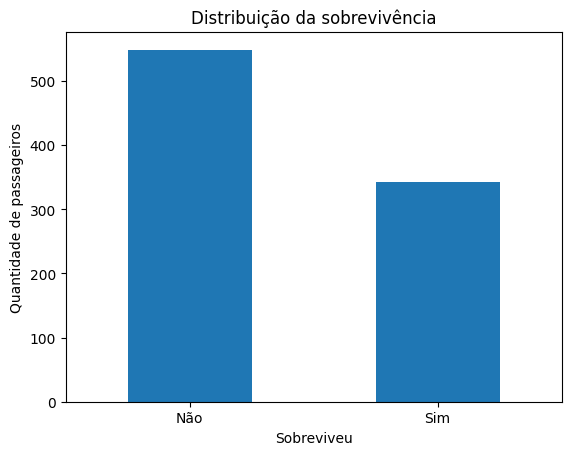

In [14]:
dados["Survived"].value_counts().sort_index().plot(kind="bar")

plt.title("Distribuição da sobrevivência")
plt.xlabel("Sobreviveu")
plt.ylabel("Quantidade de passageiros")
plt.xticks([0, 1], ["Não", "Sim"], rotation=0)
plt.show()

### Interpretação do gráfico

O gráfico mostra que a quantidade de passageiros que não sobreviveram foi maior do que a quantidade de sobreviventes. Dos 891 passageiros presentes no conjunto de dados, 549 não sobreviveram e 342 sobreviveram. Portanto, a classe 0 é a mais frequente no atributo-alvo.

In [15]:
dados.groupby("Sex")["Survived"].mean() * 100

,Survived
Sex,
female,74.203822
male,18.890815


### Sobrevivência por sexo

A taxa de sobrevivência foi significativamente maior entre as mulheres. Aproximadamente 74,20% das passageiras sobreviveram, enquanto entre os homens a taxa foi de cerca de 18,89%. Esse resultado indica uma forte relação entre o sexo do passageiro e a sobrevivência no conjunto de dados.

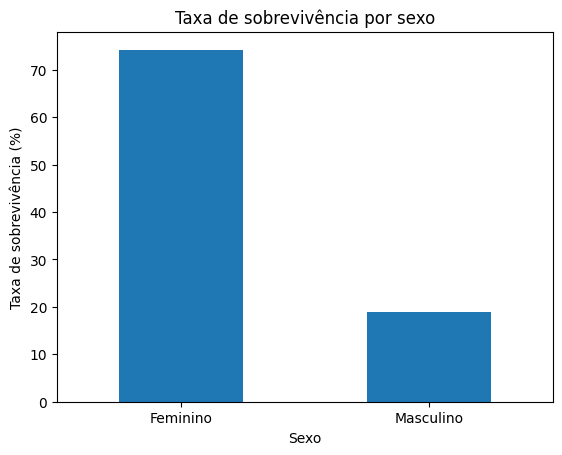

In [16]:
(dados.groupby("Sex")["Survived"].mean() * 100).plot(kind="bar")

plt.title("Taxa de sobrevivência por sexo")
plt.xlabel("Sexo")
plt.ylabel("Taxa de sobrevivência (%)")
plt.xticks([0, 1], ["Feminino", "Masculino"], rotation=0)
plt.show()

### Interpretação do gráfico

O gráfico mostra que a taxa de sobrevivência foi muito maior entre as mulheres. Aproximadamente 74,20% das passageiras sobreviveram, enquanto entre os homens a taxa foi de cerca de 18,89%. Dessa forma, observa-se uma forte relação entre o sexo do passageiro e a sobrevivência no conjunto de dados.

In [17]:
dados.groupby("Pclass")["Survived"].mean() * 100

,Survived
Pclass,
1,62.962963
2,47.282609
3,24.236253


### Sobrevivência por classe

A taxa de sobrevivência foi maior entre os passageiros da primeira classe, chegando a aproximadamente 62,96%. Na segunda classe, a taxa foi de 47,28%, enquanto na terceira classe apenas 24,24% dos passageiros sobreviveram. Esses resultados indicam uma relação entre a classe da passagem e a sobrevivência no conjunto de dados.

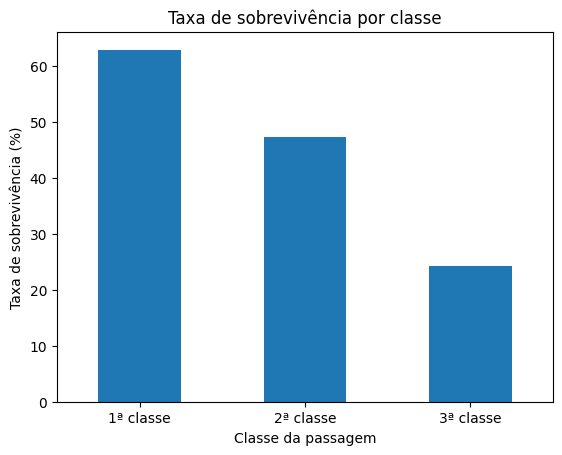

In [18]:
(dados.groupby("Pclass")["Survived"].mean() * 100).plot(kind="bar")

plt.title("Taxa de sobrevivência por classe")
plt.xlabel("Classe da passagem")
plt.ylabel("Taxa de sobrevivência (%)")
plt.xticks([0, 1, 2], ["1ª classe", "2ª classe", "3ª classe"], rotation=0)
plt.show()

### Interpretação do gráfico

O gráfico mostra que a taxa de sobrevivência foi maior entre os passageiros da primeira classe, com aproximadamente 62,96%. Na segunda classe, a taxa foi de cerca de 47,28%, enquanto na terceira classe foi de apenas 24,24%. Dessa forma, observa-se que os passageiros das classes mais elevadas apresentaram maior taxa de sobrevivência no conjunto de dados.

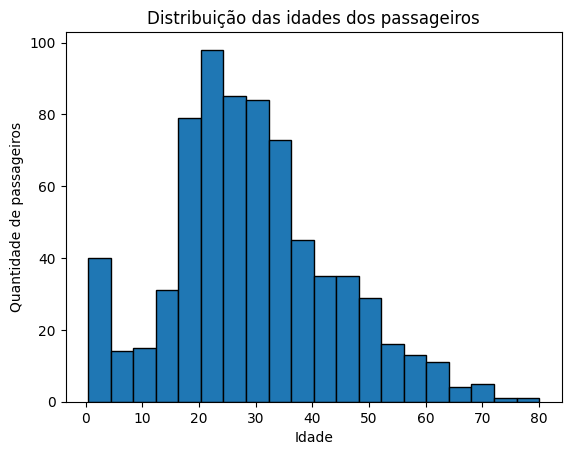

In [19]:
dados["Age"].plot(
    kind="hist",
    bins=20,
    edgecolor="black"
)

plt.title("Distribuição das idades dos passageiros")
plt.xlabel("Idade")
plt.ylabel("Quantidade de passageiros")
plt.show()

### Interpretação do gráfico

O gráfico mostra que a maior parte dos passageiros estava concentrada nas faixas de idade entre aproximadamente 20 e 30 anos. A quantidade de passageiros diminui nas idades mais elevadas, embora existam registros que chegam até 80 anos. Também há crianças no conjunto de dados. É importante destacar que 177 passageiros não possuem idade informada e, por isso, não aparecem nesse gráfico.

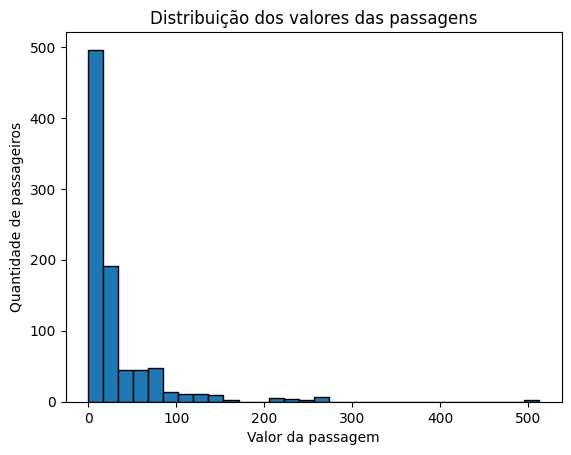

In [20]:
dados["Fare"].plot(
    kind="hist",
    bins=30,
    edgecolor="black"
)

plt.title("Distribuição dos valores das passagens")
plt.xlabel("Valor da passagem")
plt.ylabel("Quantidade de passageiros")
plt.show()

### Interpretação do gráfico

O gráfico mostra que a maior parte dos passageiros pagou valores mais baixos pelas passagens. À medida que o valor da tarifa aumenta, a quantidade de passageiros diminui. Também existem poucos registros com tarifas muito elevadas, que podem ser considerados valores extremos na distribuição.

In [21]:
dados.groupby("Embarked")["Survived"].mean() * 100

,Survived
Embarked,
C,55.357143
Q,38.961039
S,33.695652


### Sobrevivência por porto de embarque

A maior taxa de sobrevivência foi observada entre os passageiros que embarcaram em Cherbourg, com aproximadamente 55,36%. Em Queenstown, a taxa foi de cerca de 38,96%, enquanto em Southampton foi de aproximadamente 33,70%. Esses resultados indicam uma relação entre o porto de embarque e a sobrevivência no conjunto de dados.

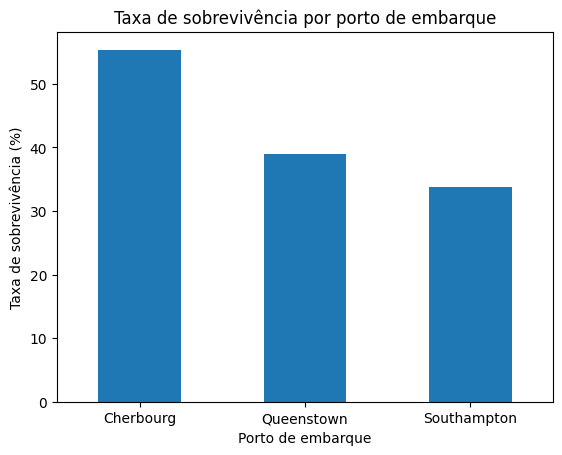

In [22]:
(dados.groupby("Embarked")["Survived"].mean() * 100).plot(kind="bar")

plt.title("Taxa de sobrevivência por porto de embarque")
plt.xlabel("Porto de embarque")
plt.ylabel("Taxa de sobrevivência (%)")
plt.xticks(
    [0, 1, 2],
    ["Cherbourg", "Queenstown", "Southampton"],
    rotation=0
)
plt.show()

### Interpretação do gráfico

O gráfico mostra que a maior taxa de sobrevivência ocorreu entre os passageiros que embarcaram em Cherbourg, com aproximadamente 55,36%. Queenstown apresentou uma taxa de cerca de 38,96%, enquanto Southampton teve a menor taxa, com aproximadamente 33,70%. Portanto, observa-se uma relação entre o porto de embarque e a sobrevivência dos passageiros.

In [23]:
dados.groupby("Survived")["Age"].mean()

,Age
Survived,
0,30.626179
1,28.343690


### Relação entre idade e sobrevivência

Os passageiros que não sobreviveram apresentaram idade média de aproximadamente 30,63 anos, enquanto os sobreviventes tiveram idade média de cerca de 28,34 anos. A diferença entre as médias é pequena, indicando que a idade, isoladamente, não apresenta uma relação tão forte com a sobrevivência quanto outras variáveis analisadas, como sexo e classe da passagem.

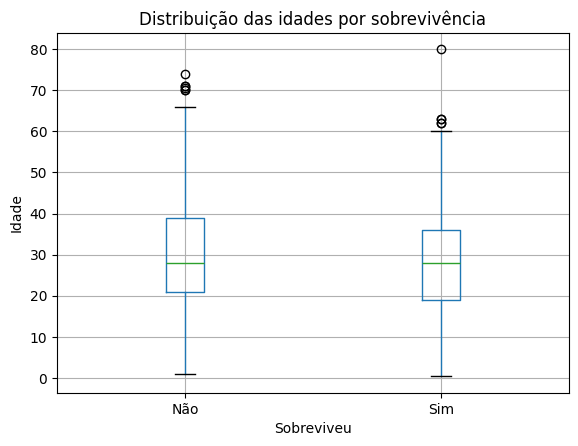

In [24]:
dados.boxplot(column="Age", by="Survived")

plt.title("Distribuição das idades por sobrevivência")
plt.suptitle("")
plt.xlabel("Sobreviveu")
plt.ylabel("Idade")
plt.xticks([1, 2], ["Não", "Sim"])
plt.show()

### Interpretação do gráfico

O gráfico mostra que as idades dos sobreviventes e dos não sobreviventes apresentam distribuições semelhantes, com grande sobreposição entre os dois grupos. A idade média dos sobreviventes foi de aproximadamente 28,34 anos, enquanto a dos não sobreviventes foi de cerca de 30,63 anos. Como a diferença é pequena, a idade isoladamente não parece ser suficiente para explicar a sobrevivência dos passageiros. Além disso, os 177 registros sem idade informada não foram considerados nesse gráfico.

In [25]:
colunas_numericas = [
    "Survived",
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare"
]

dados[colunas_numericas].corr()

,Survived,Pclass,Age,SibSp,Parch,Fare
Survived,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


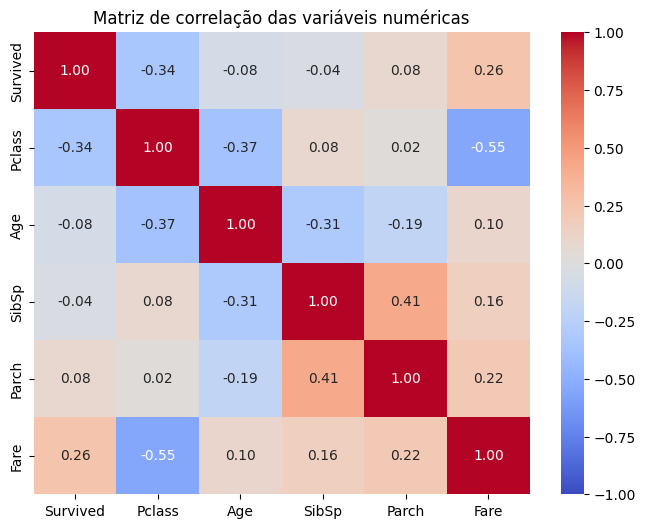

In [26]:
import seaborn as sns

correlacao = dados[colunas_numericas].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    correlacao,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title("Matriz de correlação das variáveis numéricas")
plt.show()

### Interpretação do gráfico

A matriz de correlação mostra que Pclass apresentou a maior correlação com a sobrevivência entre as variáveis numéricas, com valor aproximado de -0,34. Como os menores valores de Pclass representam as classes mais altas, essa correlação negativa indica que passageiros da primeira classe apresentaram maior tendência de sobrevivência.

A variável Fare apresentou correlação positiva de aproximadamente 0,26 com Survived, indicando que tarifas mais elevadas estiveram associadas a uma maior taxa de sobrevivência. As variáveis Age, SibSp e Parch apresentaram correlações fracas com o atributo-alvo. É importante destacar que correlação não significa necessariamente uma relação de causa e efeito.

## Pré-processamento dos dados

Nesta etapa, serão selecionadas as variáveis utilizadas pelos modelos e realizados os tratamentos necessários. O atributo-alvo será Survived, enquanto as variáveis preditivas serão Pclass, Sex, Age, SibSp, Parch, Fare e Embarked.

As colunas PassengerId, Name, Ticket e Cabin não serão utilizadas. PassengerId representa apenas um identificador, enquanto Name e Ticket possuem textos e códigos com muitos valores diferentes. A coluna Cabin apresenta 687 valores ausentes, correspondendo à maior parte dos registros.

In [27]:
colunas_preditivas = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked"
]

X = dados[colunas_preditivas]
y = dados["Survived"]

In [28]:
X.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,22.0,1,0,7.2500,S
1,1,female,38.0,1,0,71.2833,C
2,3,female,26.0,0,0,7.9250,S
3,1,female,35.0,1,0,53.1000,S
4,3,male,35.0,0,0,8.0500,S


In [29]:
from sklearn.model_selection import train_test_split

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [30]:
print("Tamanho do conjunto de treinamento:", X_treino.shape)
print("Tamanho do conjunto de teste:", X_teste.shape)

Tamanho do conjunto de treinamento: (712, 7)
Tamanho do conjunto de teste: (179, 7)


### Separação dos dados

Os dados foram divididos em 80% para treinamento e 20% para teste. Dessa forma, 712 registros foram destinados ao treinamento dos modelos e 179 registros ficaram reservados para a avaliação final.

Foi utilizada a estratificação pelo atributo-alvo para manter proporções semelhantes de sobreviventes e não sobreviventes nos dois conjuntos. O valor random_state=42 foi utilizado para garantir que a divisão seja reproduzida da mesma forma em novas execuções.

In [31]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [32]:
colunas_numericas = [
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare"
]

colunas_categoricas = [
    "Sex",
    "Embarked"
]

In [33]:
tratamento_numerico = Pipeline(steps=[
    ("preencher_ausentes", SimpleImputer(strategy="median")),
    ("padronizar", StandardScaler())
])

In [34]:
tratamento_categorico = Pipeline(steps=[
    ("preencher_ausentes", SimpleImputer(strategy="most_frequent")),
    ("transformar_texto", OneHotEncoder(handle_unknown="ignore"))
])

In [35]:
pre_processamento = ColumnTransformer(
    transformers=[
        ("numericas", tratamento_numerico, colunas_numericas),
        ("categoricas", tratamento_categorico, colunas_categoricas)
    ]
)

### Tratamento das variáveis

As variáveis numéricas e categóricas receberam tratamentos diferentes. Nas variáveis numéricas, os valores ausentes serão preenchidos utilizando a mediana, por ser menos influenciada por valores extremos. Também será aplicada a padronização, para que as variáveis fiquem em escalas semelhantes.

Nas variáveis categóricas, os valores ausentes serão preenchidos com a categoria mais frequente. Em seguida, os textos serão transformados em valores numéricos por meio do OneHotEncoder, permitindo que os modelos utilizem essas informações.

Os tratamentos foram organizados em um ColumnTransformer e serão aplicados apenas durante o treinamento dos modelos, evitando o vazamento de informações do conjunto de teste.

### Tratamento do desbalanceamento

A distribuição do atributo-alvo apresenta diferença entre as classes, mas não um desbalanceamento extremo. Por esse motivo, não foram aplicadas técnicas de reamostragem. Foram utilizadas estratificação na separação dos dados e métricas adicionais à acurácia, como precisão, revocação e F1-score.

## Modelagem e avaliação

Nesta etapa, serão treinados e comparados os modelos de classificação. A comparação será realizada utilizando acurácia, precisão, revocação e F1-score.

In [36]:
from sklearn.model_selection import cross_validate
from sklearn.metrics import (
    make_scorer,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

metricas = {
    "acuracia": make_scorer(accuracy_score),
    "precisao": make_scorer(precision_score, zero_division=0),
    "revocacao": make_scorer(recall_score, zero_division=0),
    "f1": make_scorer(f1_score, zero_division=0)
}

### Baseline

O baseline será utilizado como referência inicial para avaliar se os modelos de aprendizado de máquina conseguem apresentar resultados superiores a uma estratégia simples.

In [37]:
from sklearn.dummy import DummyClassifier

modelo_baseline = Pipeline(steps=[
    ("pre_processamento", pre_processamento),
    ("modelo", DummyClassifier(strategy="most_frequent"))
])

In [38]:
resultado_baseline = cross_validate(
    modelo_baseline,
    X_treino,
    y_treino,
    cv=5,
    scoring=metricas
)

print("Acurácia média:", resultado_baseline["test_acuracia"].mean())
print("Precisão média:", resultado_baseline["test_precisao"].mean())
print("Revocação média:", resultado_baseline["test_revocacao"].mean())
print("F1-score médio:", resultado_baseline["test_f1"].mean())

Acurácia média: 0.6165763813651137
Precisão média: 0.0
Revocação média: 0.0
F1-score médio: 0.0


### Resultado do baseline

O baseline apresentou acurácia média de aproximadamente 61,66%. Entretanto, sua precisão, revocação e F1-score foram iguais a zero. Isso ocorreu porque o modelo sempre previu a classe mais frequente, correspondente aos passageiros que não sobreviveram.

Embora tenha acertado a maioria dos registros, o baseline não conseguiu identificar nenhum sobrevivente. Portanto, os próximos modelos deverão superar esse resultado e apresentar capacidade de reconhecer as duas classes.

### SGDClassifier

O SGDClassifier foi utilizado como um dos modelos obrigatórios de classificação. Ele aprende a separar as classes por meio de ajustes sucessivos realizados durante o treinamento. O parâmetro `loss="log_loss"` define a função utilizada para orientar o aprendizado do modelo, enquanto `max_iter=1000` estabelece o número máximo de iterações. O parâmetro `random_state=42` foi utilizado para garantir a reprodução dos resultados.

In [39]:
from sklearn.linear_model import SGDClassifier

modelo_sgd = Pipeline(steps=[
    ("pre_processamento", pre_processamento),
    ("modelo", SGDClassifier(
        loss="log_loss",
        max_iter=1000,
        random_state=42
    ))
])

In [40]:
resultado_sgd = cross_validate(
    modelo_sgd,
    X_treino,
    y_treino,
    cv=5,
    scoring=metricas
)

print("Acurácia média:", resultado_sgd["test_acuracia"].mean())
print("Precisão média:", resultado_sgd["test_precisao"].mean())
print("Revocação média:", resultado_sgd["test_revocacao"].mean())
print("F1-score médio:", resultado_sgd["test_f1"].mean())

Acurácia média: 0.7781148429035752
Precisão média: 0.7472506601912949
Revocação média: 0.6482154882154882
F1-score médio: 0.6836984385339028


### Resultado do SGDClassifier

O SGDClassifier apresentou acurácia média de aproximadamente 77,81%, superando o resultado do baseline. A precisão foi de aproximadamente 74,73%, enquanto a revocação foi de 64,82% e o F1-score foi de 68,37%.

Esses resultados mostram que o modelo conseguiu identificar as duas classes e apresentou desempenho significativamente melhor do que a estratégia utilizada pelo baseline. Entretanto, sua revocação indica que parte dos passageiros que sobreviveram não foi identificada corretamente.

### RandomForestClassifier

O RandomForestClassifier combina várias árvores de decisão para realizar as previsões. Cada árvore analisa os dados de uma forma e a classificação final é definida pela combinação dos resultados dessas árvores. Foram utilizadas 200 árvores de decisão, definidas por `n_estimators=200`, e `random_state=42` para garantir a reprodução dos resultados.

In [41]:
from sklearn.ensemble import RandomForestClassifier

modelo_random_forest = Pipeline(steps=[
    ("pre_processamento", pre_processamento),
    ("modelo", RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

In [42]:
resultado_random_forest = cross_validate(
    modelo_random_forest,
    X_treino,
    y_treino,
    cv=5,
    scoring=metricas
)

print("Acurácia média:", resultado_random_forest["test_acuracia"].mean())
print("Precisão média:", resultado_random_forest["test_precisao"].mean())
print("Revocação média:", resultado_random_forest["test_revocacao"].mean())
print("F1-score médio:", resultado_random_forest["test_f1"].mean())

Acurácia média: 0.7894710922879936
Precisão média: 0.7295453812434944
Revocação média: 0.7146127946127947
F1-score médio: 0.7219226533245224


### Resultado do RandomForestClassifier

O RandomForestClassifier apresentou acurácia média de aproximadamente 78,95%, precisão de 72,95%, revocação de 71,46% e F1-score de 72,19%. Assim como o SGDClassifier, o modelo apresentou resultados significativamente superiores ao baseline.

Em comparação com o SGDClassifier, a Random Forest apresentou maior acurácia, revocação e F1-score, embora tenha obtido uma precisão um pouco menor. Como apresentou o melhor equilíbrio geral entre as métricas, a Random Forest será considerada inicialmente o melhor modelo entre os avaliados.

## Comparação dos modelos

Os resultados médios obtidos durante a validação cruzada serão organizados em uma tabela para facilitar a comparação entre os modelos.

In [43]:
comparacao_modelos = pd.DataFrame({
    "Modelo": [
        "Baseline",
        "SGDClassifier",
        "RandomForestClassifier"
    ],
    "Acurácia": [
        resultado_baseline["test_acuracia"].mean(),
        resultado_sgd["test_acuracia"].mean(),
        resultado_random_forest["test_acuracia"].mean()
    ],
    "Precisão": [
        resultado_baseline["test_precisao"].mean(),
        resultado_sgd["test_precisao"].mean(),
        resultado_random_forest["test_precisao"].mean()
    ],
    "Revocação": [
        resultado_baseline["test_revocacao"].mean(),
        resultado_sgd["test_revocacao"].mean(),
        resultado_random_forest["test_revocacao"].mean()
    ],
    "F1-score": [
        resultado_baseline["test_f1"].mean(),
        resultado_sgd["test_f1"].mean(),
        resultado_random_forest["test_f1"].mean()
    ]
})

comparacao_modelos.round(4)

,Modelo,Acurácia,Precisão,Revocação,F1-score
0,Baseline,0.6166,0.0000,0.0000,0.0000
1,SGDClassifier,0.7781,0.7473,0.6482,0.6837
2,RandomForestClassifier,0.7895,0.7295,0.7146,0.7219


### Interpretação da comparação

O baseline apresentou acurácia de aproximadamente 61,66%, mas não conseguiu identificar nenhum sobrevivente, resultando em precisão, revocação e F1-score iguais a zero.

O SGDClassifier apresentou melhora significativa, alcançando acurácia de 77,81% e a maior precisão entre os modelos, com 74,73%. Entretanto, sua revocação foi menor, indicando que deixou de identificar uma parcela maior dos sobreviventes.

O RandomForestClassifier apresentou a maior acurácia, com 78,95%, além da maior revocação e do maior F1-score. Por apresentar o melhor equilíbrio entre as métricas, ele foi escolhido como modelo final para avaliação no conjunto de teste.

## Avaliação final do modelo escolhido

Após a comparação por validação cruzada, o RandomForestClassifier foi escolhido como modelo final. Nesta etapa, o modelo será treinado com todo o conjunto de treinamento e avaliado no conjunto de teste, que permaneceu reservado durante a comparação.

In [44]:
modelo_random_forest.fit(X_treino, y_treino)

previsoes_teste = modelo_random_forest.predict(X_teste)

In [45]:
acuracia_final = accuracy_score(y_teste, previsoes_teste)
precisao_final = precision_score(y_teste, previsoes_teste)
revocacao_final = recall_score(y_teste, previsoes_teste)
f1_final = f1_score(y_teste, previsoes_teste)

print("Acurácia final:", acuracia_final)
print("Precisão final:", precisao_final)
print("Revocação final:", revocacao_final)
print("F1-score final:", f1_final)

Acurácia final: 0.8156424581005587
Precisão final: 0.8
Revocação final: 0.6956521739130435
F1-score final: 0.7441860465116279


### Interpretação da avaliação final

No conjunto de teste, o RandomForestClassifier apresentou acurácia de aproximadamente 81,56%, indicando que acertou a classificação da maioria dos passageiros.

A precisão foi de 80%, o que significa que, entre os passageiros classificados pelo modelo como sobreviventes, 80% realmente sobreviveram. A revocação foi de aproximadamente 69,57%, indicando que o modelo conseguiu identificar cerca de 69,57% de todos os sobreviventes presentes no conjunto de teste.

O F1-score foi de aproximadamente 74,42%, demonstrando um equilíbrio satisfatório entre precisão e revocação. Os resultados finais foram semelhantes aos obtidos durante a validação cruzada, indicando que o modelo apresentou desempenho consistente em dados que não haviam sido utilizados no treinamento.

In [46]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

matriz_confusao = confusion_matrix(y_teste, previsoes_teste)

matriz_confusao

array([[98, 12],
       [21, 48]])

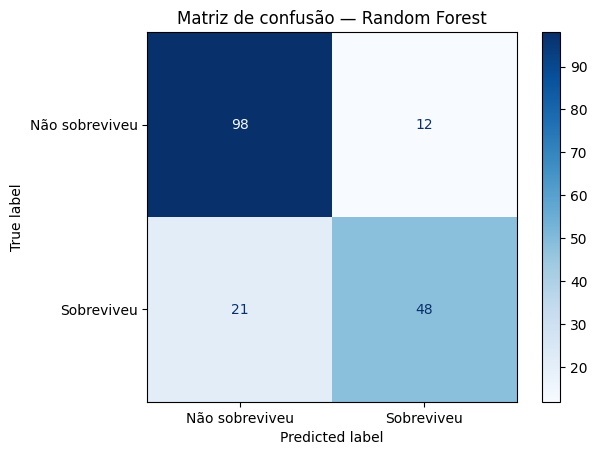

In [47]:
ConfusionMatrixDisplay.from_predictions(
    y_teste,
    previsoes_teste,
    display_labels=["Não sobreviveu", "Sobreviveu"],
    cmap="Blues"
)

plt.title("Matriz de confusão — Random Forest")
plt.show()

### Interpretação da matriz de confusão

A matriz de confusão mostra que o modelo classificou corretamente 98 passageiros que não sobreviveram e 48 passageiros que sobreviveram.

Foram observados 12 falsos positivos, correspondentes a passageiros que não sobreviveram, mas foram classificados como sobreviventes. Também ocorreram 21 falsos negativos, referentes a passageiros que sobreviveram, mas foram classificados como não sobreviventes.

No total, o modelo acertou 146 dos 179 passageiros do conjunto de teste e cometeu 33 erros. A maior quantidade de falsos negativos ajuda a explicar por que a revocação foi menor do que a precisão.

In [48]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_teste,
        previsoes_teste,
        target_names=["Não sobreviveu", "Sobreviveu"]
    )
)

                precision    recall  f1-score   support

Não sobreviveu       0.82      0.89      0.86       110
    Sobreviveu       0.80      0.70      0.74        69

      accuracy                           0.82       179
     macro avg       0.81      0.79      0.80       179
  weighted avg       0.81      0.82      0.81       179



### Interpretação do relatório de classificação

O relatório de classificação mostra que o modelo apresentou melhor desempenho na identificação dos passageiros que não sobreviveram. Para essa classe, foram obtidas precisão de 82%, revocação de 89% e F1-score de 86%.

Para a classe dos sobreviventes, o modelo apresentou precisão de 80%, revocação de 70% e F1-score de 74%. Isso indica que, embora as previsões de sobrevivência tenham apresentado boa precisão, o modelo deixou de identificar parte dos passageiros que realmente sobreviveram.

O conjunto de teste possuía 110 não sobreviventes e 69 sobreviventes. A acurácia geral foi de aproximadamente 82%, confirmando os resultados apresentados anteriormente pela matriz de confusão e pelas métricas finais.

## Discussão dos resultados, erros e limitações

O RandomForestClassifier apresentou desempenho satisfatório, alcançando acurácia de aproximadamente 81,56% no conjunto de teste. Entretanto, o modelo não conseguiu classificar corretamente todos os passageiros. Foram observados 12 falsos positivos e 21 falsos negativos.

A maior quantidade de falsos negativos indica que o modelo apresentou mais dificuldade para identificar todos os passageiros que realmente sobreviveram. Esse comportamento também pode ser observado na revocação da classe dos sobreviventes, que foi de aproximadamente 70%.

Uma das limitações do projeto é a presença de valores ausentes, especialmente na coluna Age. Esses valores foram preenchidos com a mediana, mas as idades reais dos passageiros poderiam apresentar informações diferentes. A coluna Cabin não foi utilizada por possuir muitos valores ausentes, embora a localização da cabine pudesse ter relação com a sobrevivência.

Também não foram utilizadas diretamente as colunas Name e Ticket, pois exigiriam tratamentos mais avançados. Informações como o título presente no nome do passageiro, o tamanho da família e a localização aproximada da cabine poderiam ser criadas e testadas em trabalhos futuros.

Outra limitação é que o conjunto de dados possui apenas 891 registros e representa um acontecimento histórico específico. Portanto, os resultados encontrados não devem ser interpretados como relações de causa e efeito nem generalizados para outras situações.

Como possíveis melhorias, poderiam ser realizados ajustes nos parâmetros dos modelos, criação de novas variáveis, comparação com outros algoritmos e utilização de técnicas mais avançadas para tratar valores ausentes e valores extremos.

## Conclusão

Este projeto teve como objetivo desenvolver modelos de aprendizado de máquina capazes de prever a sobrevivência dos passageiros do Titanic a partir de informações como sexo, idade, classe da passagem, tarifa, quantidade de familiares a bordo e porto de embarque.

Durante a análise exploratória, foram observadas relações importantes entre a sobrevivência e variáveis como sexo e classe da passagem. Também foram identificados valores ausentes, especialmente nas colunas Age e Cabin, além da necessidade de transformar variáveis categóricas em valores numéricos.

Foram comparados um baseline, o SGDClassifier e o RandomForestClassifier. O baseline apresentou acurácia de aproximadamente 61,66%, mas não conseguiu identificar nenhum sobrevivente. O SGDClassifier apresentou melhora significativa, enquanto o RandomForestClassifier obteve o melhor equilíbrio geral entre as métricas.

Na avaliação final, o RandomForestClassifier alcançou acurácia de aproximadamente 81,56%, precisão de 80%, revocação de 69,57% e F1-score de 74,42%. Apesar dos resultados satisfatórios, o modelo ainda apresentou erros, principalmente na identificação de alguns passageiros que sobreviveram.

Conclui-se que os modelos de aprendizado de máquina conseguiram identificar padrões relevantes no conjunto de dados e apresentar resultados superiores ao baseline. Entretanto, as previsões possuem limitações e não devem ser interpretadas como explicações causais para a sobrevivência dos passageiros.